# Retail Demand Forecasting

This notebook demonstrates an end-to-end forecasting pipeline using the Retail Store Inventory Dataset.
We will aggregate daily sales to weekly product-store sales, explore the data, train baseline models, 
and evaluate forecasts using various metrics.

### Goals
- Aggregate transactional sales to weekly product-store level.
- Explore seasonality and trends.
- Train and compare multiple forecasting models.
- Evaluate forecasts and provide insights for inventory and sales planning.

### 1. Setup and Dependencies

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

#forecasting/model libs
from prophet import Prophet
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("all modules loaded successfully")

all modules loaded successfully


### 2. Load and Inspect Dataset

In [63]:
#load dataset
df = pd.read_csv('../data/retail_store_inventory.csv')
print("Shape:", df.shape)

#overview
df.head()

Shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [65]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [66]:
#check missing values
print("Missing value per col")
df.isnull().sum()

Missing value per col


Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

### 3. Preprocessing and Exploration
Before modelling lets start by getting an overview over the data, and potentially see if there any obvious correlations or potential biasies.

In [67]:
#ensure Date column exists, and adapt if necessary
df['Date'] = pd.to_datetime(df['Date'])

#sort the DataFrame by 'Date'
df = df.sort_values(by='Date').reset_index(drop=True)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,0,Sunny,0,63.92,Autumn
2,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,5,Rainy,1,18.56,Spring
3,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,0,Sunny,1,57.76,Spring
4,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,0,37.15,Summer


Overview of the sales quantity across the entire dataset. Is there any standout periodes or clear seasonalities. 

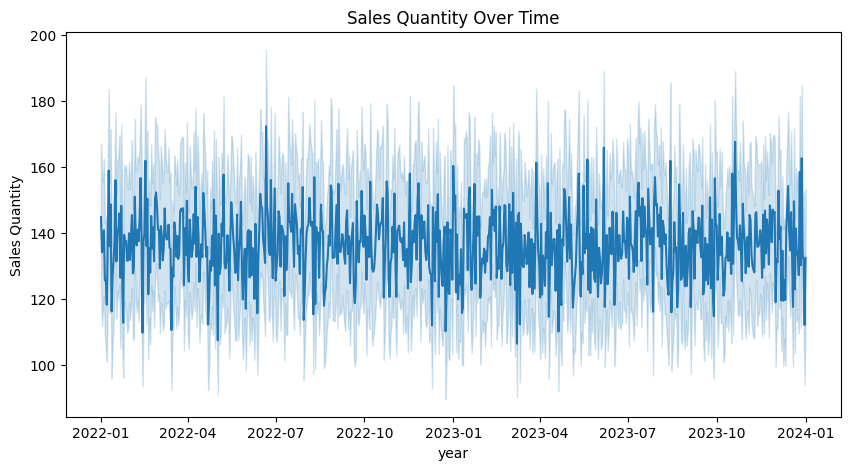

In [68]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Date', y='Units Sold')
plt.title("Sales Quantity Over Time")
plt.xlabel("year")
plt.ylabel("Sales Quantity")
plt.show()

The recorded weekly demand across the timespan of the dataset. Start and end is likely starting in the middle of a periode hence has less total units sold that week, creating the sudden start adn drop.

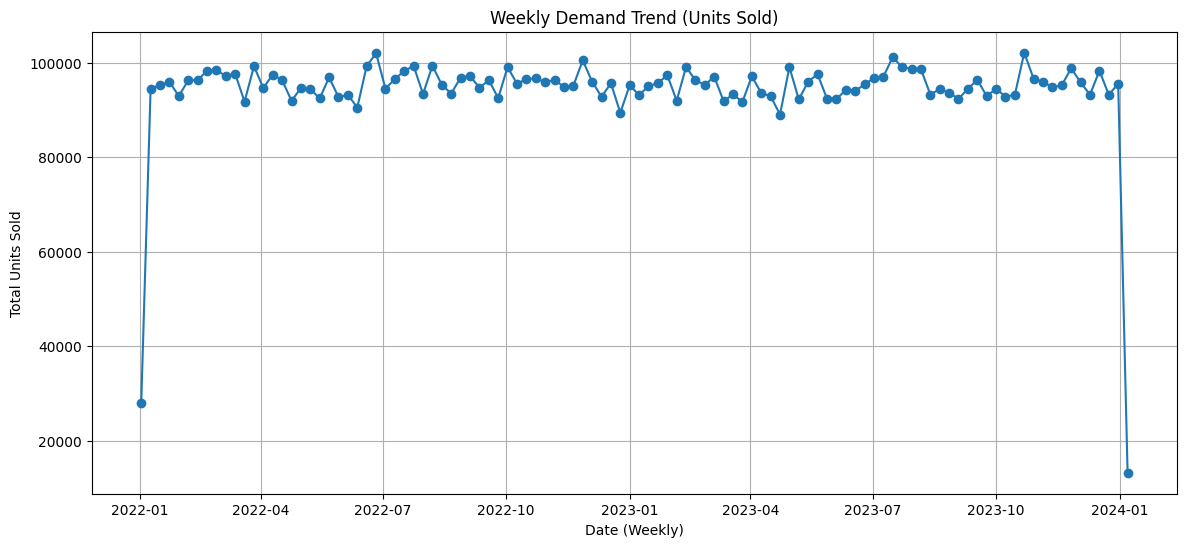

In [69]:
#group by actual Date week
weekly_demand = df.resample('W', on='Date')['Units Sold'].sum().reset_index()

#plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(weekly_demand['Date'], weekly_demand['Units Sold'], marker='o')
plt.title("Weekly Demand Trend (Units Sold)")
plt.xlabel("Date (Weekly)")
plt.ylabel("Total Units Sold")
plt.grid(True)
plt.show()

Elaborating on the weekly demand by adding the category into the plot showcases that all categories act the roughly the same, and swing around the same amount of units sold.

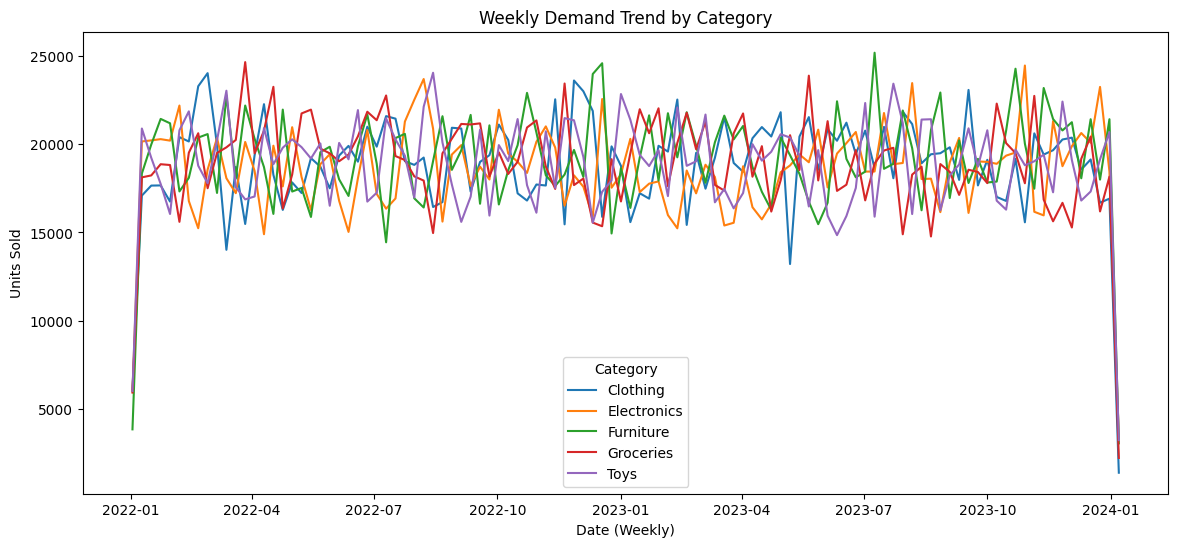

In [70]:
#weekly demand by category
weekly_cat = df.set_index('Date').groupby('Category').resample('W')['Units Sold'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=weekly_cat, x="Date", y="Units Sold", hue="Category")
plt.title("Weekly Demand Trend by Category")
plt.xlabel("Date (Weekly)")
plt.ylabel("Units Sold")
plt.legend(title="Category")
plt.show()

The pre recorded demand forecast vs the actual amount of sold units.
These seem to follow eachother extremely closely, which would be extremely odd if not for the fact that the dataset is generated and not from realworld data. Looking at the prior plots and this one you could maybe guess that the demand forecast in the dataset is made by either using a mean of the units sold of straightup adding an amount from them.

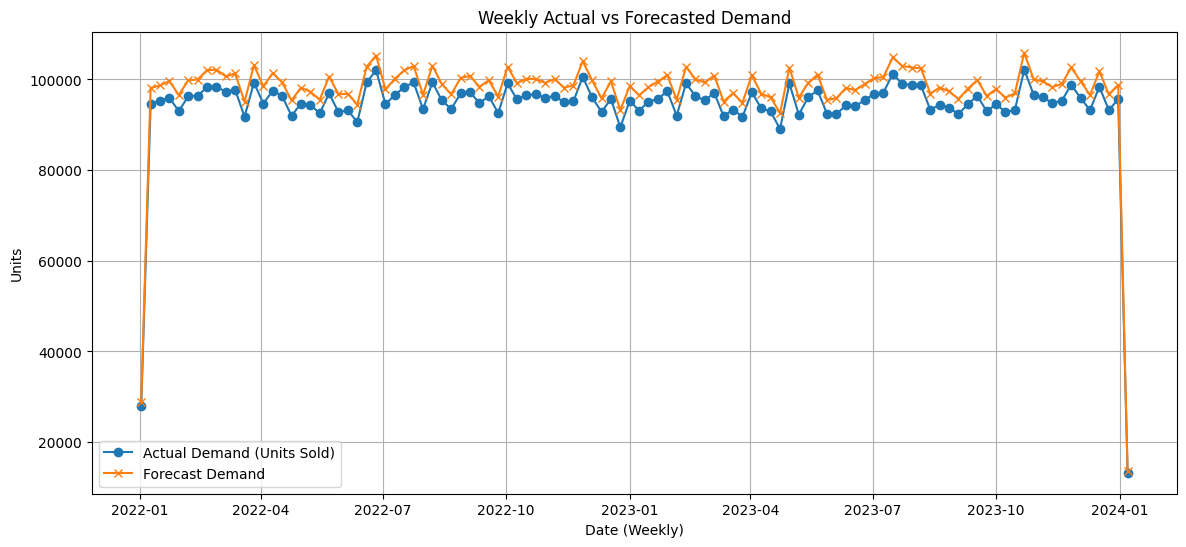

In [71]:
weekly_compare = df.resample('W', on='Date')[['Units Sold','Demand Forecast']].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(weekly_compare['Date'], weekly_compare['Units Sold'], label="Actual Demand (Units Sold)", marker='o')
plt.plot(weekly_compare['Date'], weekly_compare['Demand Forecast'], label="Forecast Demand", marker='x')
plt.title("Weekly Actual vs Forecasted Demand")
plt.xlabel("Date (Weekly)")
plt.ylabel("Units")
plt.legend()
plt.grid(True)
plt.show()

Week-by-week % change - Shows a huge change at the start/end week of the dataset

In [72]:
weekly_change = df.resample('W', on='Date')['Units Sold'].sum().reset_index()
weekly_change['WoW Change (%)'] = weekly_change['Units Sold'].pct_change() * 100

weekly_change.head(10)
weekly_change.tail(10)

,Date,Units Sold,WoW Change (%)
96,2023-11-05,96021,-0.642578
97,2023-11-12,94812,-1.259100
98,2023-11-19,95286,0.499937
99,2023-11-26,98877,3.768654
100,2023-12-03,95876,-3.035084
101,2023-12-10,93234,-2.755643
102,2023-12-17,98369,5.507647
103,2023-12-24,93248,-5.205908
104,2023-12-31,95607,2.529813
105,2024-01-07,13244,-86.147458


Investigating the seasonality within the data, there seems to be no difference between which specific day of the week sells more, however there are slight diviations within the comparison of the months. This difference between the months is likely cause by the differing amount of days within each bin.

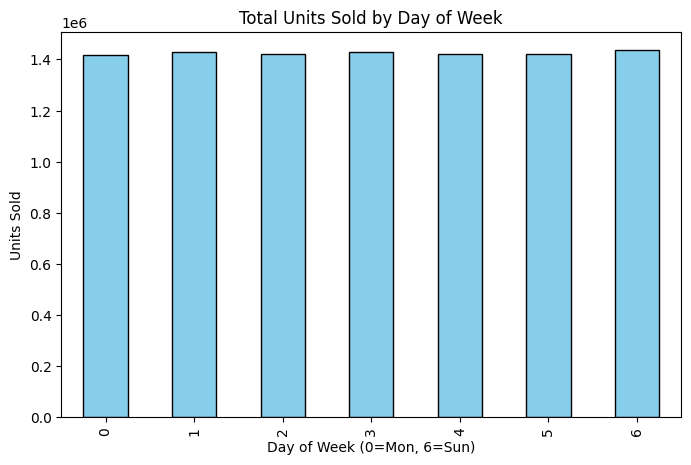

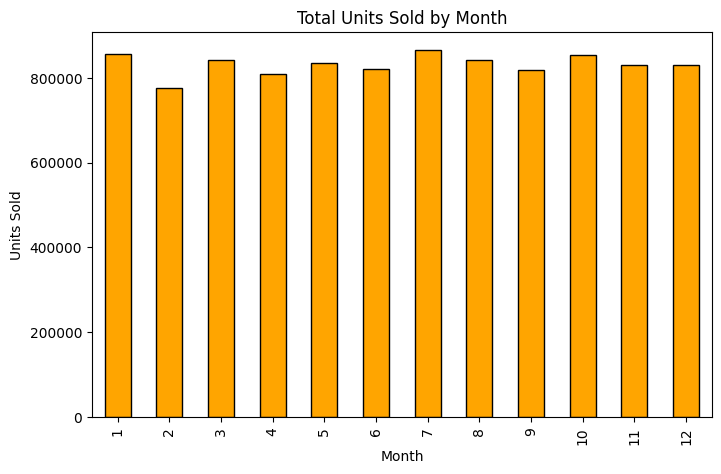

In [73]:
#day of Week Pattern (0=Monday, 6=Sunday)
df['DayOfWeek'] = df['Date'].dt.dayofweek
dow_sales = df.groupby('DayOfWeek')['Units Sold'].sum()

plt.figure(figsize=(8,5))
dow_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Total Units Sold by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Units Sold")
plt.show()

#monthly Pattern
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Units Sold'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Total Units Sold by Month")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

Checking the corelation between features, can add an idea to which features are important in relation to eachother.

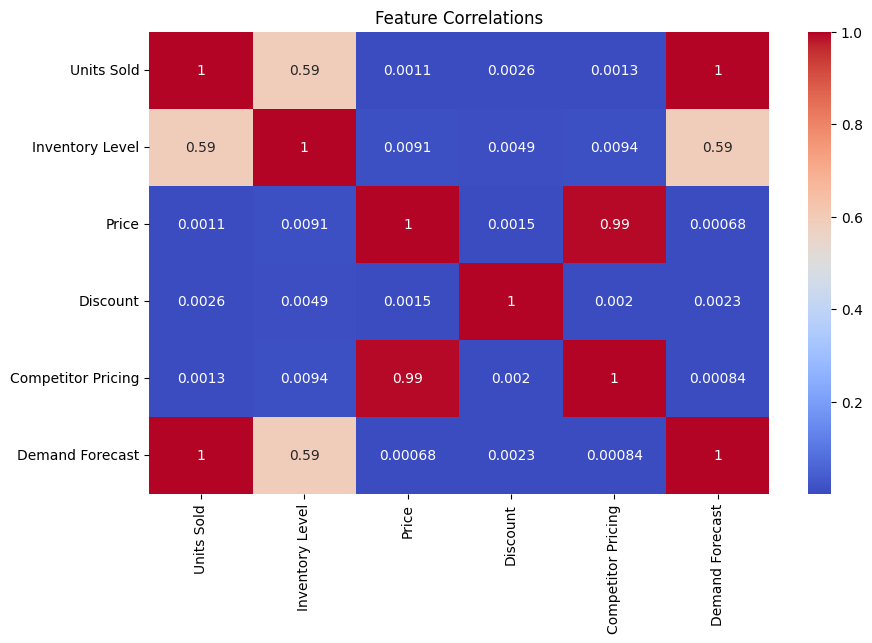

In [74]:
cols = df[['Units Sold', 'Inventory Level', 'Price','Discount','Competitor Pricing', 'Demand Forecast']]
plt.figure(figsize=(10,6))
sns.heatmap(cols.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlations")
plt.show()

Since the dataset includes a premade demand forecast, we can compare how these turned out to the actual sales that was made. This can be done by fx. using a matric like RMSE or MAE.

In [75]:
#By week
weekly_compare = df.resample('W', on="Date")[['Units Sold', 'Demand Forecast']].sum()

mae = mean_absolute_error(weekly_compare['Units Sold'], weekly_compare['Demand Forecast'])
rmse = root_mean_squared_error(weekly_compare['Units Sold'], weekly_compare['Demand Forecast'])

print("Forecast Accuracy:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Forecast Accuracy:
MAE: 3468.70
RMSE: 3497.26


In [76]:
#each entry
mae = mean_absolute_error(df['Units Sold'], df['Demand Forecast'])
rmse = root_mean_squared_error(df['Units Sold'], df['Demand Forecast'])

print("Forecast Accuracy:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Forecast Accuracy:
MAE: 8.34
RMSE: 10.02


### 4 Initial demand forecast with prophet

18:02:33 - cmdstanpy - INFO - Chain [1] start processing
18:02:33 - cmdstanpy - INFO - Chain [1] done processing


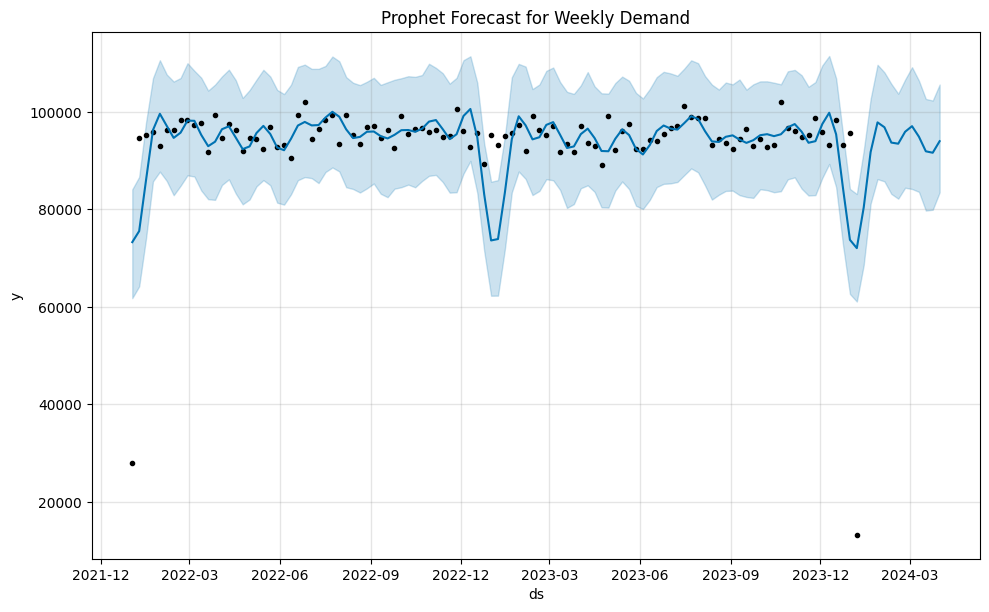

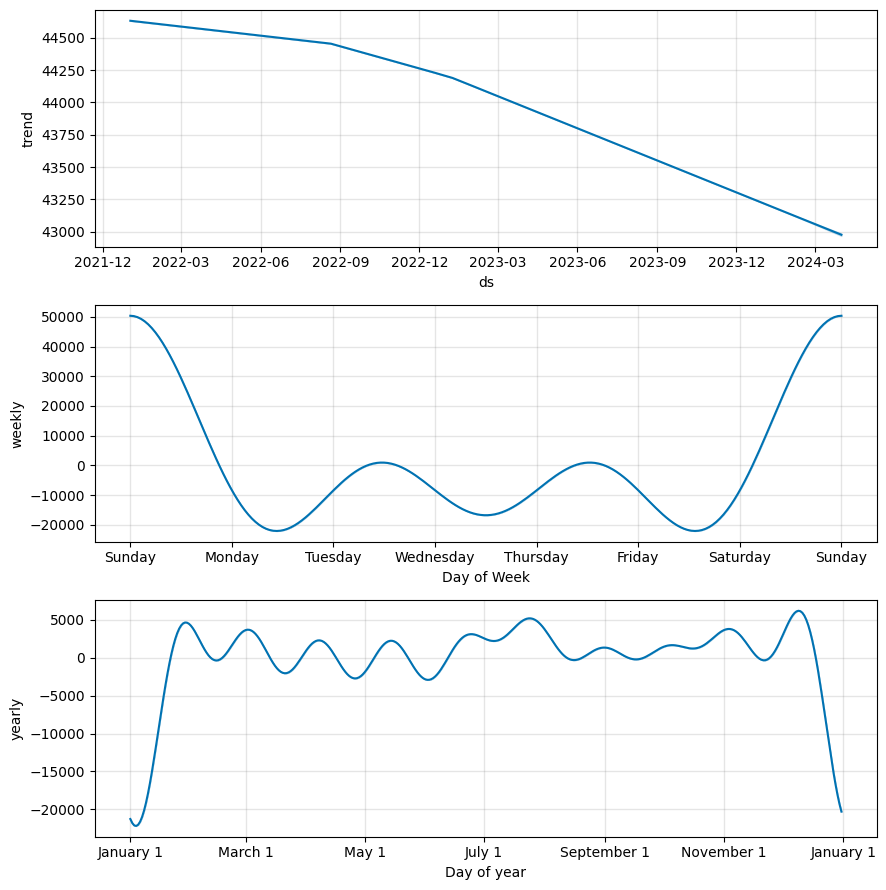

In [77]:
#prepare data
weekly = df.resample('W', on='Date')['Units Sold'].sum().reset_index()
weekly.rename(columns={'Date':'ds','Units Sold':'y'}, inplace=True)

#build model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(weekly)

#forecast next 12 weeks
future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

#plot
fig = model.plot(forecast)
plt.title("Prophet Forecast for Weekly Demand")
plt.show()

#components (trend + seasonality)
fig2 = model.plot_components(forecast)
plt.show()

Because of the outlier at the start and the end of the dataset being located at the yearly change, the model understands each yearly change as a dip. To improve this the two outliers should be removed. 

#### Evaluating the prohpet model
The model above is trained on the entire dataset, to evaluate how it is actually performing we need a train and test split, where the test split will be used to validate the result of the model.

In [78]:
#lets start by removing the 2 outleirs
weekly = weekly.iloc[1:-1].reset_index(drop=True)

In [79]:
#split into train/test
train = weekly[:-12]
test = weekly[-12:]

#train the model on the training set
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(train)

#ake future dataframe for same length as test
future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future) #generate forecast

#select the forecasted (future) part only
forecast_test = forecast.tail(12)
comparison = test.copy()
comparison['yhat'] = forecast_test['yhat'].values
comparison['yhat_lower'] = forecast_test['yhat_lower'].values
comparison['yhat_upper'] = forecast_test['yhat_upper'].values
comparison.head()

#evaluation
y_true = comparison['y']
y_pred = comparison['yhat']

# use evaluation metrics
mae = mean_absolute_error(y_true, y_pred)        
rmse = root_mean_squared_error(y_true, y_pred)      
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

18:02:34 - cmdstanpy - INFO - Chain [1] start processing
18:02:35 - cmdstanpy - INFO - Chain [1] done processing


MAE: 2348.70
RMSE: 3065.51
MAPE: 2.41%


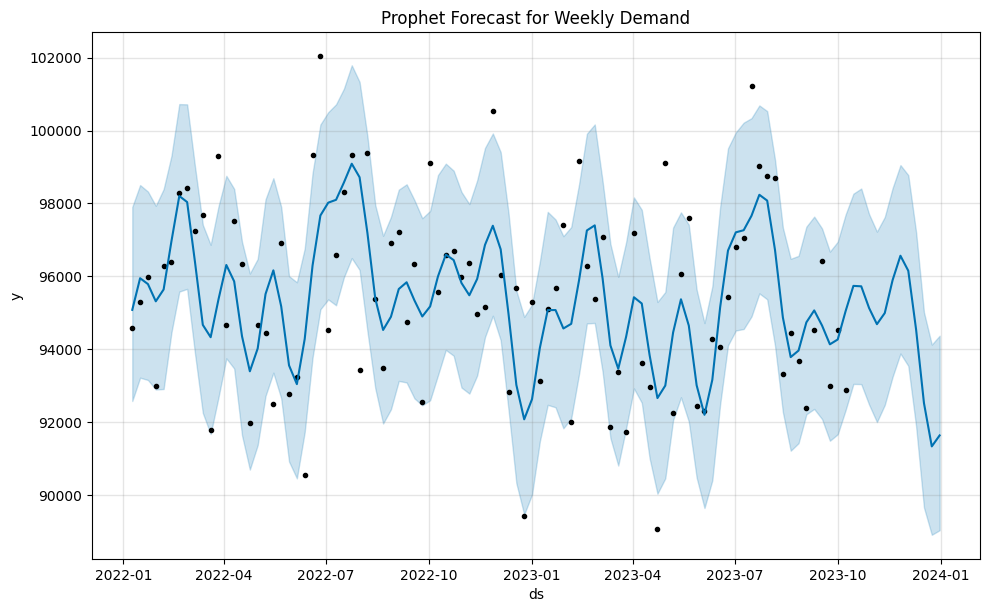

In [80]:
#Entire fit to test-set
fig = model.plot(forecast)
plt.title("Prophet Forecast for Weekly Demand")
plt.show()

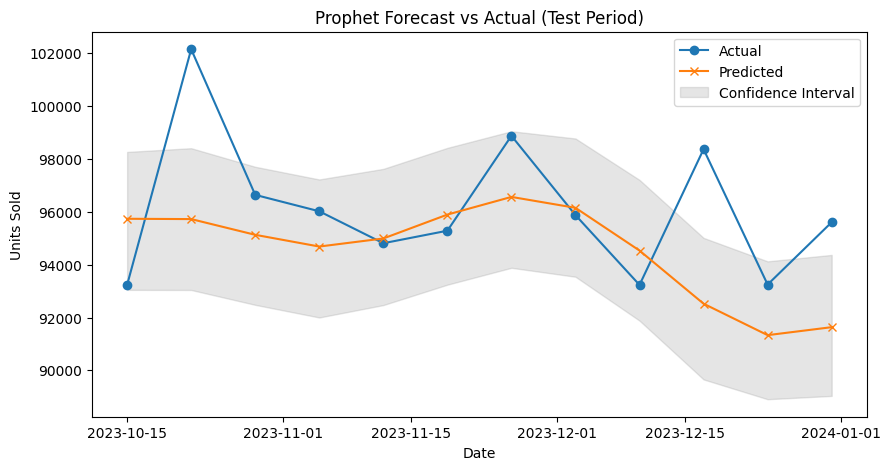

In [81]:
#fit to only the future 12 weeks from when the model was trained
plt.figure(figsize=(10,5))
plt.plot(test['ds'], test['y'], label='Actual', marker='o')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Predicted', marker='x')
plt.fill_between(forecast_test['ds'], 
                 forecast_test['yhat_lower'], 
                 forecast_test['yhat_upper'], 
                 color='gray', alpha=0.2, label='Confidence Interval')
plt.title("Prophet Forecast vs Actual (Test Period)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

### 5 Evalutating other models
We can setup of models that utilize other methods to also perform a forecast and then evaluate them to compare how well they perform.

In [82]:
#evaluation functions
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE (Mean Absolute Percentage Error)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero_idx = y_true != 0
    return np.mean(np.abs((y_true[nonzero_idx] - y_pred[nonzero_idx]) / y_true[nonzero_idx])) * 100

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"{name:10} | MAE: {mae:8.3f} | RMSE: {rmse:8.3f} | R2: {r2:6.3f} | MAPE: {mape:6.2f}%")

In [83]:
#use same train and test as before
y_train = train['y'].values
y_test = test['y'].values

#create a timeindex
train_lr = train.copy()
test_lr = test.copy()

train_lr['week'] = train_lr['ds'].dt.isocalendar().week
train_lr['year'] = train_lr['ds'].dt.year
test_lr['week'] = test_lr['ds'].dt.isocalendar().week
test_lr['year'] = test_lr['ds'].dt.year

features_lr = ['week', 'year']

lr = LinearRegression()
lr.fit(train_lr[features_lr], train_lr['y'])

y_pred_lr = lr.predict(test_lr[features_lr])

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr)/y_test)) * 100

print(f"Linear Regression -> MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, MAPE: {mape_lr:.2f}%")



Linear Regression -> MAE: 2018.68, RMSE: 2758.34, MAPE: 2.06%


In [84]:
train_sarimax = train.set_index('ds')
test_sarimax = test.set_index('ds')

# SARIMAX with yearly seasonality (s=52 weeks)
model_sarimax = SARIMAX(train_sarimax['y'],
                        order=(1,1,1),
                        seasonal_order=(1,1,1,52),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
sarimax_fit = model_sarimax.fit(disp=False)

y_pred_sarimax = sarimax_fit.forecast(steps=12)

mae_sarimax = mean_absolute_error(y_test, y_pred_sarimax)
rmse_sarimax = root_mean_squared_error(y_test, y_pred_sarimax)
mape_sarimax = np.mean(np.abs((y_test - y_pred_sarimax)/y_test)) * 100

print(f"SARIMAX -> MAE: {mae_sarimax:.2f}, RMSE: {rmse_sarimax:.2f}, MAPE: {mape_sarimax:.2f}%")

c:\Users\Jonas R. Jørgensen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\Jonas R. Jørgensen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\Jonas R. Jørgensen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMAX -> MAE: 3067.79, RMSE: 3660.39, MAPE: 3.17%


In [88]:
def create_lags(df, lags=[1,2,3,4,12]):
    for lag in lags:
        df[f'lag_{lag}'] = df['y'].shift(lag)
    return df

rf_data = create_lags(weekly.copy())
rf_data['week'] = rf_data['ds'].dt.isocalendar().week
rf_data = rf_data.dropna().reset_index(drop=True)

train_rf = rf_data.iloc[:len(train)]
test_rf = rf_data.iloc[len(train):len(train)+len(test)]

features_rf = [col for col in train_rf.columns if 'lag' in col] + ['week']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(train_rf[features_rf], train_rf['y'])

y_pred_rf = rf.predict(test_rf[features_rf])

mae_rf = mean_absolute_error(test_rf['y'], y_pred_rf)
rmse_rf = root_mean_squared_error(test_rf['y'], y_pred_rf)
mape_rf = np.mean(np.abs((test_rf['y'] - y_pred_rf)/test_rf['y'])) * 100

print(f"Random Forest -> MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, MAPE: {mape_rf:.2f}%")

ValueError: Found array with 0 sample(s) (shape=(0, 6)) while a minimum of 1 is required by RandomForestRegressor.

In [50]:
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(train_rf[features_rf], train_rf['y'])

y_pred_xgb = xgb_model.predict(test_rf[features_rf])

mae_xgb = mean_absolute_error(test_rf['y'], y_pred_xgb)
rmse_xgb = root_mean_squared_error(test_rf['y'], y_pred_xgb)
mape_xgb = np.mean(np.abs((test_rf['y'] - y_pred_xgb)/test_rf['y'])) * 100

print(f"XGBoost -> MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, MAPE: {mape_xgb:.2f}%")

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.